# makeshift — quick start

The core workflow: fetch a BMRB entry, get tidy chemical shifts, simulate an HSQC, handle multi-entity entries, and compute the Chemical Shift Index (CSI).

In [1]:
import makeshift as ms
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Fetch a BMRB entry

`ChemicalShifts.from_bmrb` downloads the NMR-STAR file and parses it into a tidy dataframe — one row per chemical shift, in `cs.data`.

In [2]:
# Unphosphorylated NtrCr (Volkman & Kern 2001)
cs = ms.ChemicalShifts.from_bmrb(4527)
cs.data.head()

,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,ChemShift_ID
0,1,2,<NA>,GLN,CA,C,55.70,chemical_shift_set_1
1,1,2,<NA>,GLN,HA,H,4.52,chemical_shift_set_1
2,1,2,<NA>,GLN,CB,C,30.00,chemical_shift_set_1
3,1,2,<NA>,GLN,HB2,H,2.12,chemical_shift_set_1
4,1,2,<NA>,GLN,HB3,H,2.03,chemical_shift_set_1


Key columns: `Seq_ID` (residue number), `Comp_ID` (3-letter residue), `Atom_ID`, `Atom_type` (element), `Val` (shift, ppm), `Entity_ID`.

## 2. Simulate an HSQC

Pivot to one row per residue with N and H columns.

Text(0.5, 1.0, 'Simulated HSQC — NtrCr (4527)')

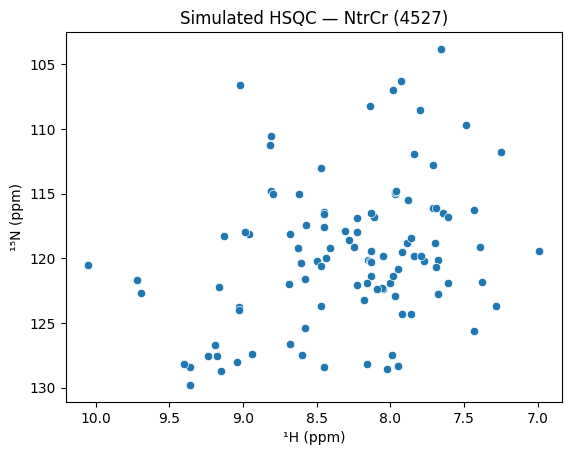

In [3]:
hsqc = (
    cs.data[cs.data['Atom_ID'].isin(['N', 'H'])]
    .pivot_table(index=['Seq_ID', 'Comp_ID'], columns='Atom_ID', values='Val')
    .reset_index()
)

sns.scatterplot(x='H', y='N', data=hsqc)
plt.gca().invert_xaxis(); plt.gca().invert_yaxis()
plt.xlabel('¹H (ppm)'); plt.ylabel('¹⁵N (ppm)')
plt.title('Simulated HSQC — NtrCr (4527)')

## 3. Multi-entity entries

Some entries hold several entities (protein + DNA + ligand). `sequences()` lists them.

In [4]:
# hERR2 zinc finger bound to DNA
cs = ms.ChemicalShifts.from_bmrb(5363)
cs.sequences()

,entity,ID,Polymer_type,Polymer_seq_one_letter_code
0,hERR2,1,polypeptide(L),AIPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPAT...
1,DNA_strand1,2,polydeoxyribonucleotide,GCTCAAGGTCACG
2,DNA_strand2,3,polydeoxyribonucleotide,CGTGACCTTGAGC
3,ZN,4,.,.


In [5]:
# keep only the polypeptide entity
ents = cs.sequences()
protein_ids = ents.loc[ents['Polymer_type'] == 'polypeptide(L)', 'ID']
cs.data[cs.data['Entity_ID'].isin(protein_ids)].head()

,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,ChemShift_ID
0,1,1,97,ALA,CA,C,49.85,chemical_shifts_1
1,1,1,97,ALA,HA,H,4.11,chemical_shifts_1
2,1,1,97,ALA,CB,C,20.08,chemical_shifts_1
3,1,1,97,ALA,HB1,H,1.48,chemical_shifts_1
4,1,1,97,ALA,HB2,H,1.48,chemical_shifts_1


## 4. Chemical Shift Index (CSI)

`calc_csi=True` adds `csi_raw` (the (CA−CB) secondary shift: positive = helix, negative = strand) and `csi` (discretised to ±1 / 0).

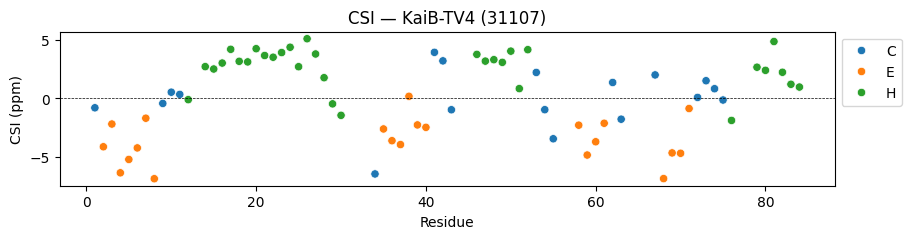

In [6]:
# KaiB-TV4 — known secondary structure
cs = ms.ChemicalShifts.from_bmrb(31107, calc_csi=True)

seq = 'MYVFRLYVRGETHAAEVALKNLHDLLSSALKVPYTLKVVDVTKQPDLAEKDQVQATPTLVRVYPQPVRRLVGQLDHRYRLQHLLSP'
dss = 'CEEEEEEECCCHHHHHHHHHHHHHHHHHHHCCCCEEEEEECCCHHHHHHHHHCCCCCEEEECCCCCCEEEECCCCHHHHHHHHHHC'

tmp = cs.data[cs.data['Atom_type'] == 'N'].copy()
tmp['dssp'] = tmp['Seq_ID'].map(lambda i: dss[i - 1])

plt.figure(figsize=(10, 2))
sns.scatterplot(x='Seq_ID', y='csi_raw', hue='dssp', data=tmp)
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.xlabel('Residue'); plt.ylabel('CSI (ppm)')
plt.title('CSI — KaiB-TV4 (31107)'); plt.legend(bbox_to_anchor=(1, 1))

# 5. Check sample conditions

In [7]:
# Denatured 
cs = ms.ChemicalShifts.from_bmrb(51260)
denatured = cs.entry.is_denatured()
methyl = cs.entry.is_methyl_labeled()
deuter = cs.entry.is_deuterated()
print(f'Denatured: {denatured}')
print(f'Deuterated: {deuter}')
print(f'Methyl labeled: {methyl}')
cs.entry.sample_info()


Denatured: True
Deuterated: False
Methyl labeled: False


,sample,ID,Sample_ID,Mol_common_name,Entity_ID,Isotopic_labeling,Concentration_val,Concentration_val_units
0,sample_1,1,1,'Helix 1 from HHR23A ubiquitin-associated doma...,1,'[U-13C; U-15N]',0.21,mM
1,sample_1,2,1,'sodium phosphate',.,'natural abundance',50,mM
2,sample_1,3,1,NaCl,.,'natural abundance',100,mM
3,sample_1,4,1,'guanidine hydrochloride',.,'natural abundance',4,M
4,sample_2,1,2,'Helix 1 from HHR23A ubiquitin-associated doma...,1,'[U-13C; U-15N]',0.21,mM
5,sample_2,2,2,'sodium phosphate',.,'natural abundance',50,mM
6,sample_2,3,2,NaCl,.,'natural abundance',100,mM
7,sample_2,4,2,'guanidine hydrochloride',.,'natural abundance',5,M
8,sample_3,1,3,'Helix 1 from HHR23A ubiquitin-associated doma...,1,'[U-13C; U-15N]',0.21,mM
9,sample_3,2,3,'sodium phosphate',.,'natural abundance',50,mM
